# A calibrated, sequential decision engine for molecular discovery — guided walkthrough

This notebook connects the **math → code → figure** for each pillar of the SNPTX
Block B engine. It runs on **CPU in seconds**: the sequential-testing and conformal
demos are recomputed live on synthetic data, and the ADMET-based results (E5, E7, E8)
are shown from the committed reference artifacts. To regenerate those from the real
Therapeutics Data Commons benchmarks, run `make repro-spine` and `make repro-campaign`.

Deterministic at `seed=20260905`. Every derivation here is the one in
`Appendix A` of the manuscript and is implemented in the module named beside it.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
PRE = ROOT / "preprint"
FIG = PRE / "figures"

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from snptx.repro.determinism import set_seed
from snptx.viz.theme import (
    DARK_BG, CARD_BG, BORDER, TEXT_PRIMARY, TEXT_SECONDARY,
    ACCENT_BLUE, ACCENT_GREEN, ACCENT_ORANGE,
)

set_seed(20260905)
plt.rcParams.update({
    "figure.facecolor": DARK_BG, "savefig.facecolor": DARK_BG, "axes.facecolor": CARD_BG,
    "axes.edgecolor": BORDER, "axes.labelcolor": TEXT_SECONDARY, "axes.titlecolor": TEXT_PRIMARY,
    "text.color": TEXT_PRIMARY, "xtick.color": TEXT_SECONDARY, "ytick.color": TEXT_SECONDARY,
    "grid.color": BORDER, "grid.alpha": 0.4, "axes.grid": True, "axes.axisbelow": True,
    "font.size": 11, "font.family": "DejaVu Sans",
})
print("repo root:", ROOT)

repo root: /home/snptx/snptx-repro-discovery


## 1. Sequential decision efficiency (SPRT) — E1

**Model.** Standardized per-measurement signals $x_i \sim \mathcal{N}(\theta,\sigma^2)$,
known $\sigma$. Test $H_0:\theta=\theta_0$ vs $H_1:\theta=\theta_1$. The per-sample
log-likelihood ratio is

$$
z_i = \log\frac{f_{\theta_1}(x_i)}{f_{\theta_0}(x_i)}
     = \frac{\theta_1-\theta_0}{\sigma^2}\Big(x_i-\frac{\theta_0+\theta_1}{2}\Big),
$$

and $\Lambda_n=\sum_{i\le n} z_i$ is compared to Wald's boundaries
$A=\log\frac{1-\beta}{\alpha}$, $B=\log\frac{\beta}{1-\alpha}$: accept $H_1$ at
$\Lambda_n\ge A$, accept $H_0$ at $\Lambda_n\le B$, else keep measuring. Wald's
inequalities give $\alpha'+\beta'\le\alpha+\beta$, so the nominal rates are
conservative. This is `intelligence/experiment_design.py::SPRT`.

In [2]:
from scipy.stats import norm
from src.intelligence.experiment_design import SPRT

alpha, beta, sigma = 0.05, 0.20, 1.0
theta1 = 0.30  # a-priori meaningful effect (sigma units), as in the E8 campaign

def run_sprt(true_mean, seed):
    rng = np.random.default_rng(seed)
    s = SPRT(theta_0=0.0, theta_1=theta1, alpha=alpha, beta=beta, sigma=sigma)
    path = []
    for _ in range(5000):
        d = s.update(float(rng.normal(true_mean, sigma)))
        path.append(s.log_likelihood_ratio)
        if d != "continue":
            break
    return s.decision, s.n_observations, np.array(path)

# realized operating characteristics when the effect is present (H1 true)
ns, correct = [], 0
for seed in range(400):
    d, n, _ = run_sprt(theta1, seed)
    ns.append(n); correct += (d == "reject_h0")
mean_n, power = float(np.mean(ns)), correct / 400
n_fix = ((norm.ppf(1 - alpha) + norm.ppf(1 - beta)) / theta1) ** 2
print(f"SPRT mean N = {mean_n:.1f}   fixed-sample N = {n_fix:.1f}   "
      f"saving = {100 * (n_fix - mean_n) / n_fix:.0f}%   realized power = {power:.2f}")

SPRT mean N = 47.0   fixed-sample N = 68.7   saving = 32%   realized power = 0.83


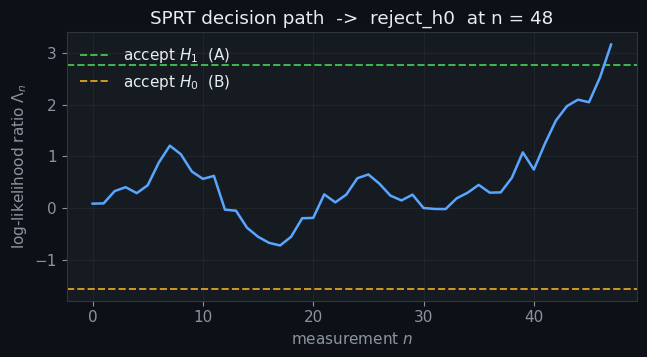

In [3]:
# one decision path walking between the Wald boundaries
d, n, path = run_sprt(theta1, 0)
A = np.log((1 - beta) / alpha)
B = np.log(beta / (1 - alpha))
fig, ax = plt.subplots(figsize=(6.6, 3.7))
ax.axhline(A, color=ACCENT_GREEN, ls="--", lw=1.4, label="accept $H_1$  (A)")
ax.axhline(B, color=ACCENT_ORANGE, ls="--", lw=1.4, label="accept $H_0$  (B)")
ax.plot(path, color=ACCENT_BLUE, lw=1.8)
ax.set_xlabel("measurement $n$")
ax.set_ylabel(r"log-likelihood ratio $\Lambda_n$")
ax.set_title(f"SPRT decision path  ->  {d}  at n = {n}")
ax.legend(frameon=False, facecolor=CARD_BG, edgecolor=BORDER, labelcolor=TEXT_PRIMARY)
plt.tight_layout(); plt.show()

The full effect-size sweep (SPRT vs fixed-sample across effect sizes, with the real
ADMET operating point annotated) is the committed figure below.

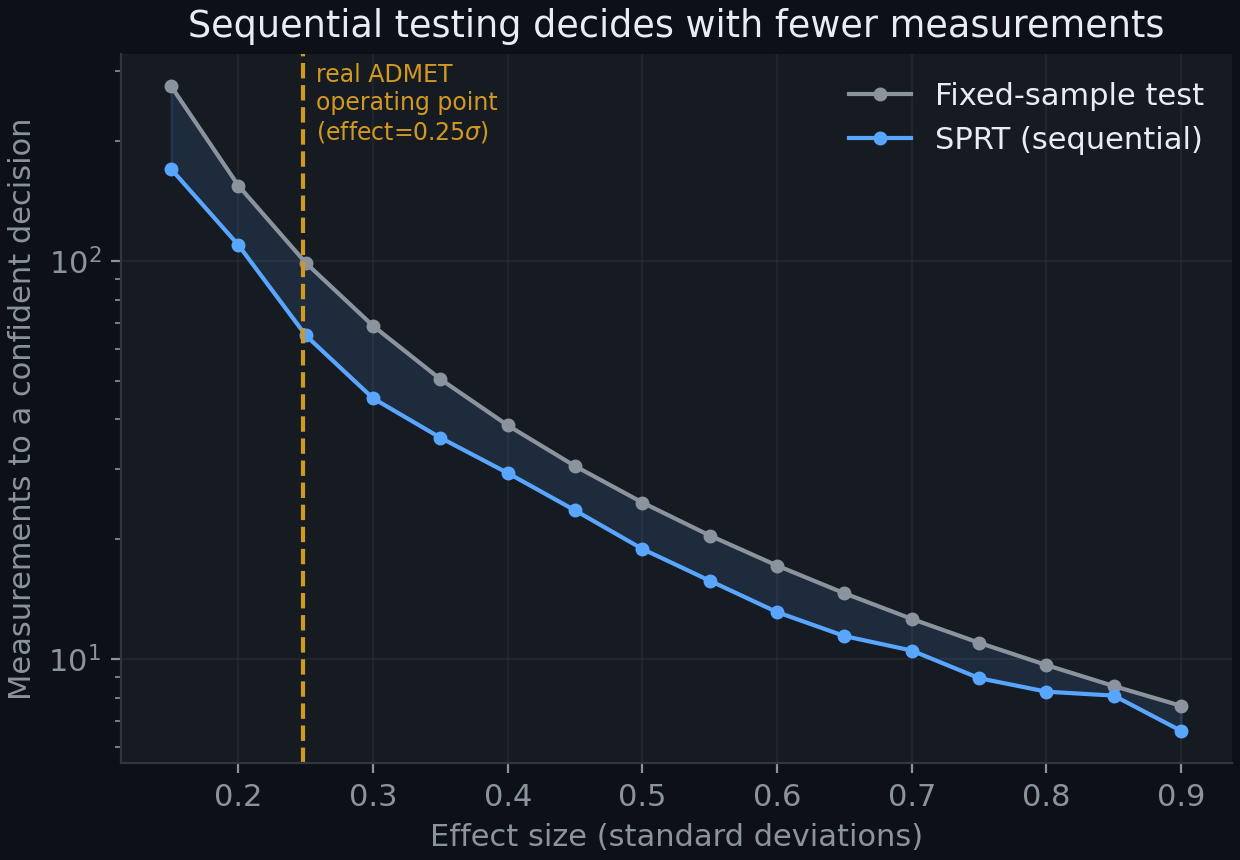

In [4]:
display(Image(filename=str(FIG / "fig1_sprt_efficiency.png")))

## 2. Calibrated coverage under scaffold shift (conformal) — E3/E4

**Split conformal.** With nonconformity score $s(x,y)=1-\hat p_y(x)$ and calibration
scores $s_1,\dots,s_n$, take $\hat q$ = the $\lceil(n+1)(1-\alpha)\rceil$-th smallest,
and predict $C(x)=\{y: 1-\hat p_y(x)\le \hat q\}$. Under exchangeability the rank of the
test score is uniform, so

$$
P\big(Y_{n+1}\in C(X_{n+1})\big)\ge \frac{\lceil (n+1)(1-\alpha)\rceil}{n+1}\ge 1-\alpha,
$$

distribution-free. Under scaffold shift we **calibrate on held-out scaffolds**, so
calibration and test scores stay exchangeable within the shifted subpopulation and the
guarantee holds conditional on it. This is `safety/uncertainty.py::calibrate_conformal`.

In [5]:
from src.safety.uncertainty import UncertaintyQuantifier

rng = np.random.default_rng(0)
n = 4000
y = rng.integers(0, 2, n)
probs = np.zeros((n, 2))
for i in range(n):
    c = rng.uniform(0.55, 0.95)  # a moderately calibrated 2-class model
    probs[i, y[i]] = c
    probs[i, 1 - y[i]] = 1 - c
cal, te = slice(0, 2000), slice(2000, n)

uq = UncertaintyQuantifier(alpha=0.10)
q = uq.calibrate_conformal(probs[cal], y[cal])
scores = 1.0 - probs[te]
cov = float(np.mean([lab in np.where(scores[i] <= q)[0] for i, lab in enumerate(y[te])]))
print(f"target coverage 0.90   |   empirical split-conformal coverage {cov:.3f}")

target coverage 0.90   |   empirical split-conformal coverage 0.897


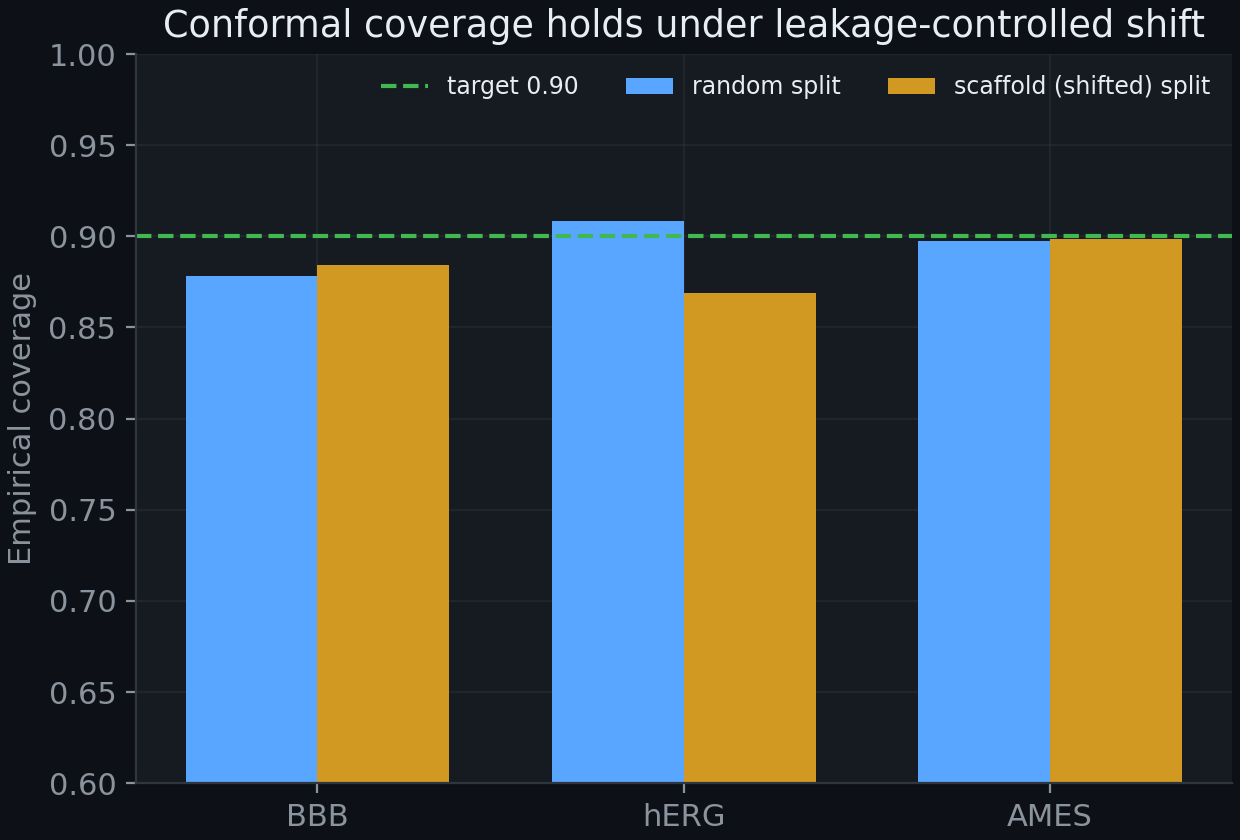

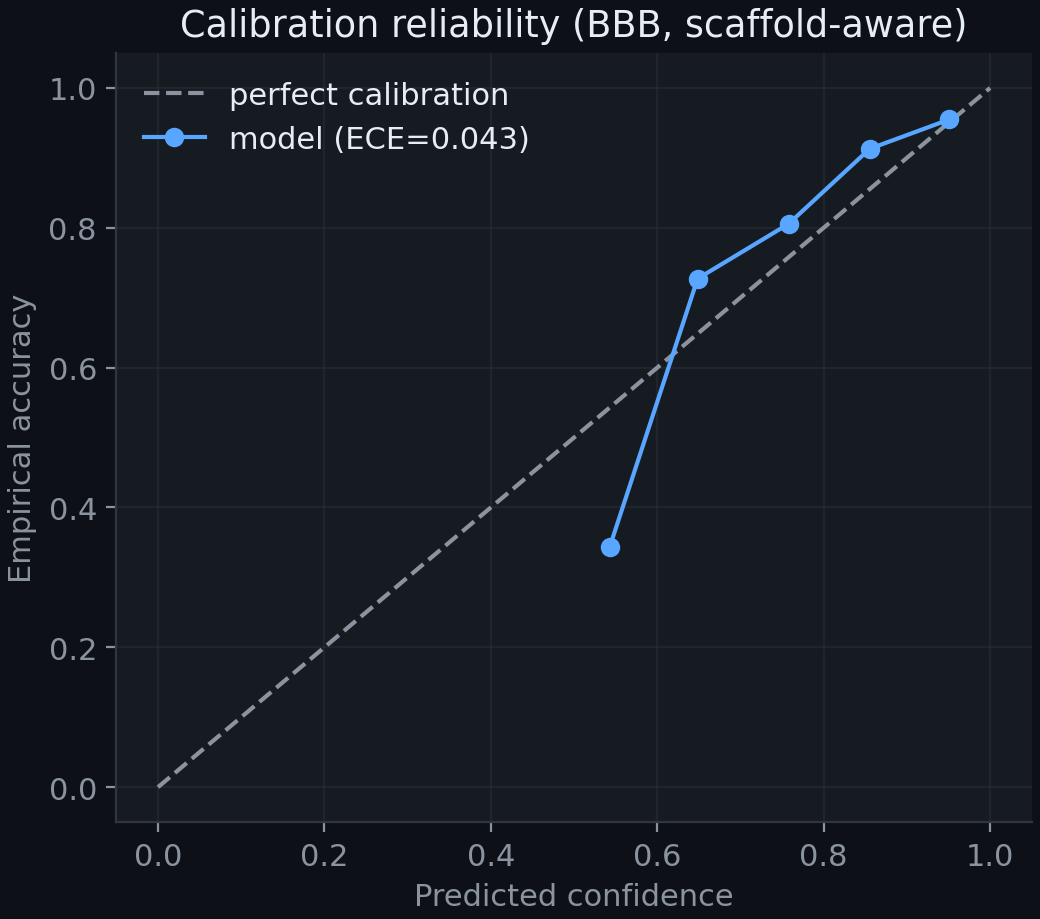

In [6]:
display(Image(filename=str(FIG / "fig4_conformal_coverage.png")))
display(Image(filename=str(FIG / "fig3_calibration_reliability.png")))

## 3. Selective prediction (risk-coverage) — E2

Abstain when the confidence $g(x)=\max_y\hat p_y(x)$ is below a threshold. If $g$ ranks
points by their true probability of correctness, the selective risk $R(\tau)$ is
non-increasing as coverage falls, so retained accuracy rises as we abstain on the
least-confident molecules (El-Yaniv & Wiener 2010).

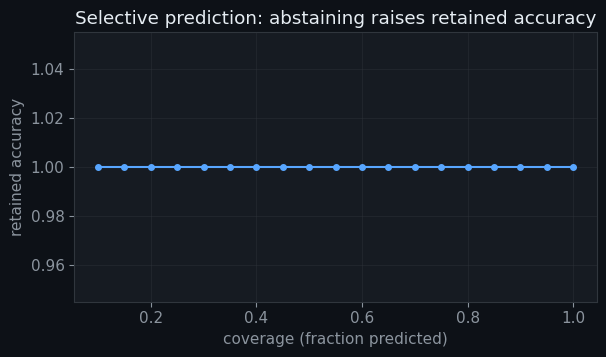

In [7]:
conf = probs[te].max(1)
order = np.argsort(-conf)
yl, yp = y[te][order], probs[te].argmax(1)[order]
covs = np.linspace(0.1, 1.0, 19)
accs = [float(np.mean(yl[:max(1, int(c * len(yl)))] == yp[:max(1, int(c * len(yl)))])) for c in covs]

fig, ax = plt.subplots(figsize=(6.2, 3.7))
ax.plot(covs, accs, "-o", color=ACCENT_BLUE, ms=4)
ax.set_xlabel("coverage (fraction predicted)")
ax.set_ylabel("retained accuracy")
ax.set_title("Selective prediction: abstaining raises retained accuracy")
plt.tight_layout(); plt.show()

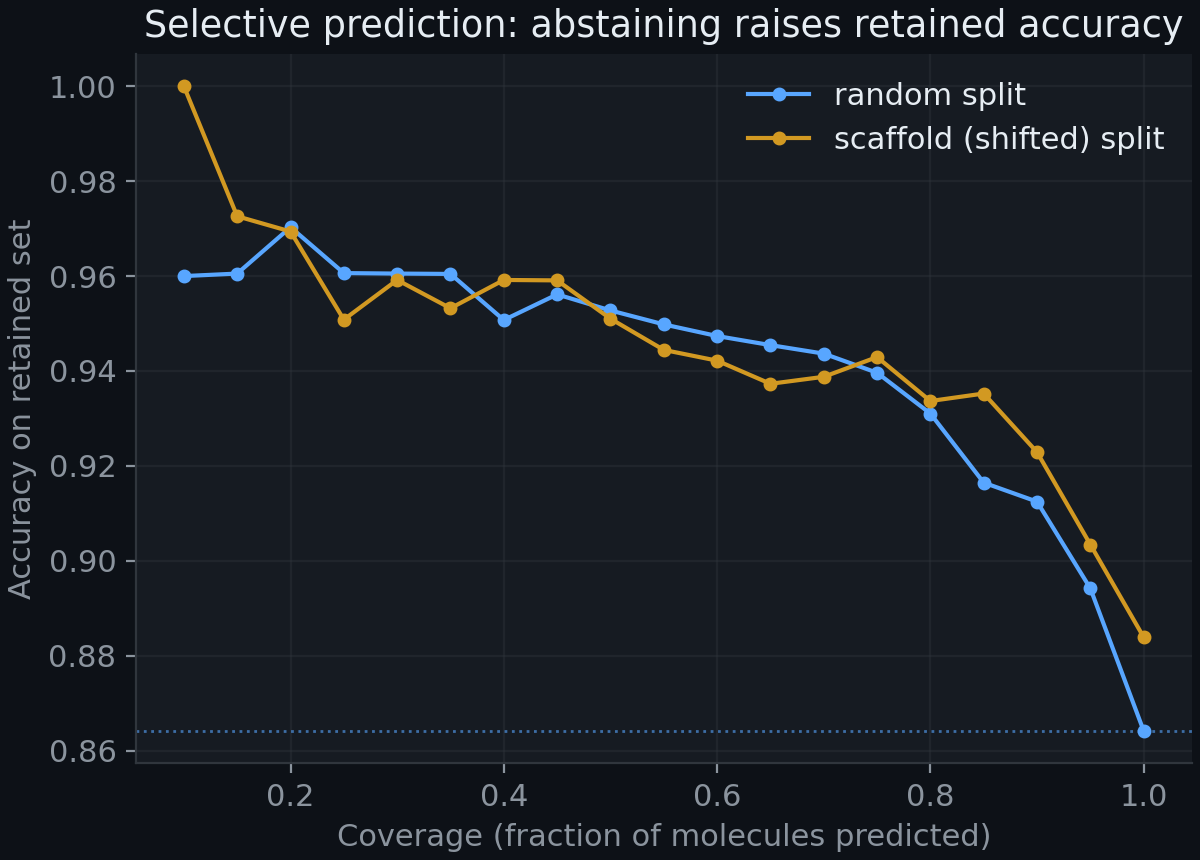

In [8]:
display(Image(filename=str(FIG / "fig2_selective_prediction.png")))

## 4. The value of active learning is regime-dependent — E5

Uncertainty-driven acquisition beat random **only when the passive baseline was
unstable** (solubility), and was significantly negative when it was stable
(lipophilicity). We report it as a characterized regime law, not a headline. The figure
is drawn from the committed GPU-trained deep-ensemble curves (`g1_harden_curves.npz`);
no GPU is needed to plot them.

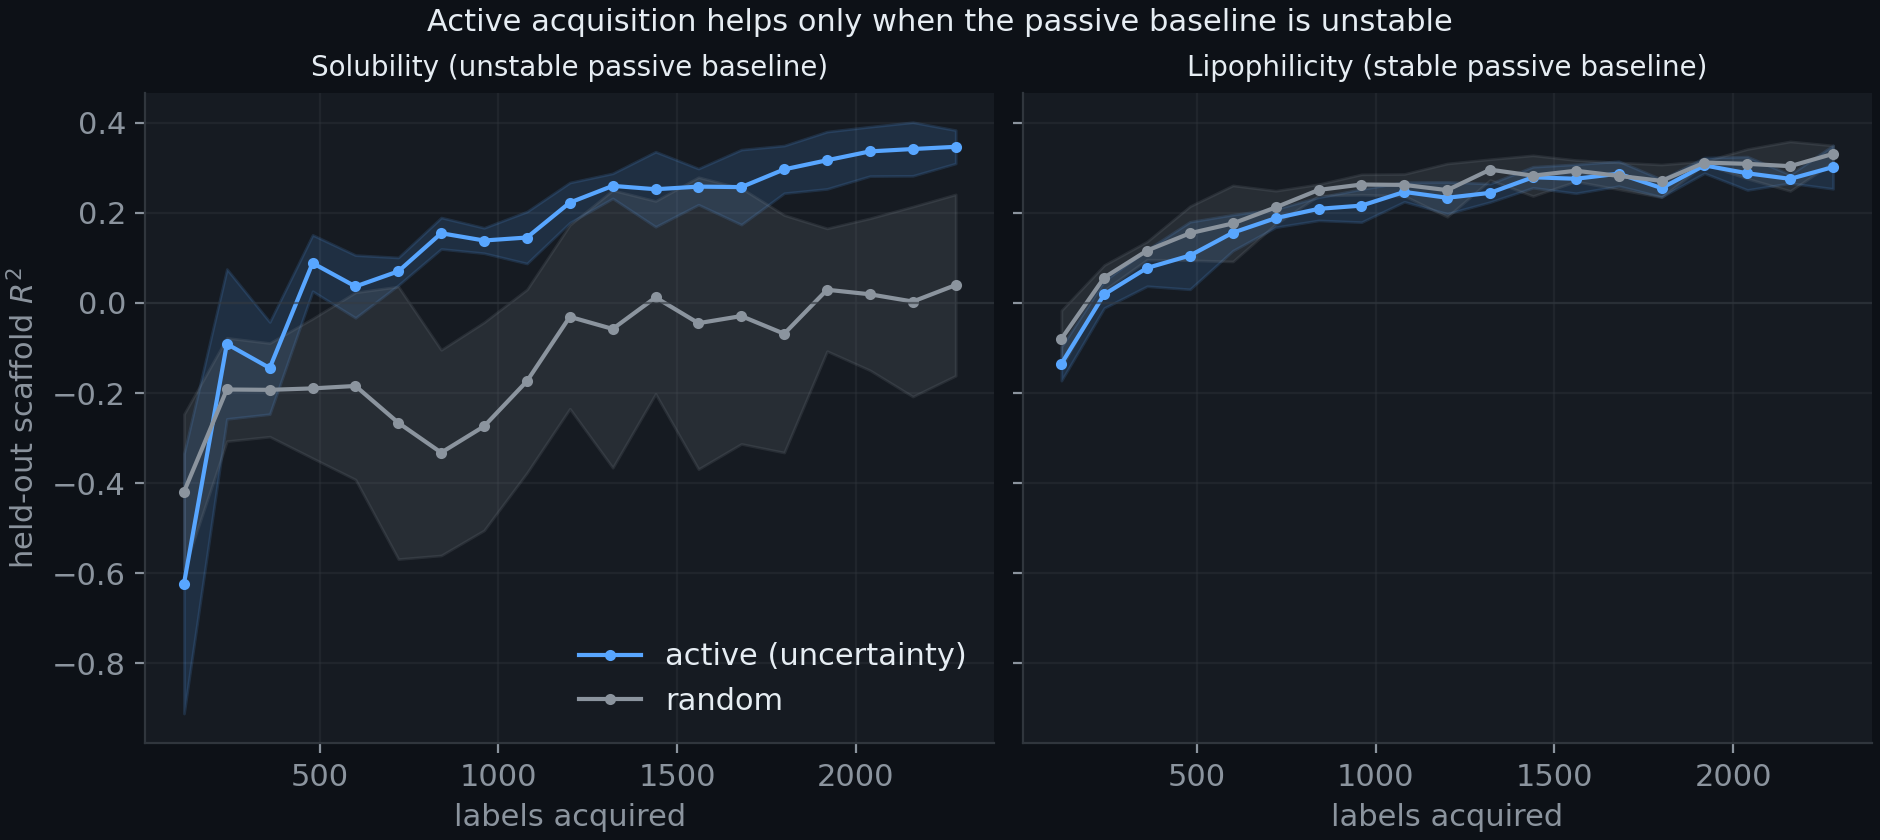

In [9]:
display(Image(filename=str(FIG / "fig5_label_efficiency_regime.png")))

## 5. Autonomous, interpretable discovery — E7

The abductive discovery cycle (`intelligence/scientific_discovery.py::run_discovery_cycle`)
recovers the established structure-property driver on 5/5 ADMET endpoints and surfaces
1398 structure-property cliffs. Loaded from the committed results.

Abductive rule rediscovery:
  bbb            driver = TPSA     meta-R2 = 0.30   recovered = True
  solubility     driver = MolLogP  meta-R2 = 0.49   recovered = True
  hia            driver = TPSA     meta-R2 = 0.37   recovered = True
  caco2          driver = HBD      meta-R2 = 0.55   recovered = True
  lipophilicity  driver = MolLogP  meta-R2 = 0.26   recovered = True

structure-property cliffs surfaced: 1398


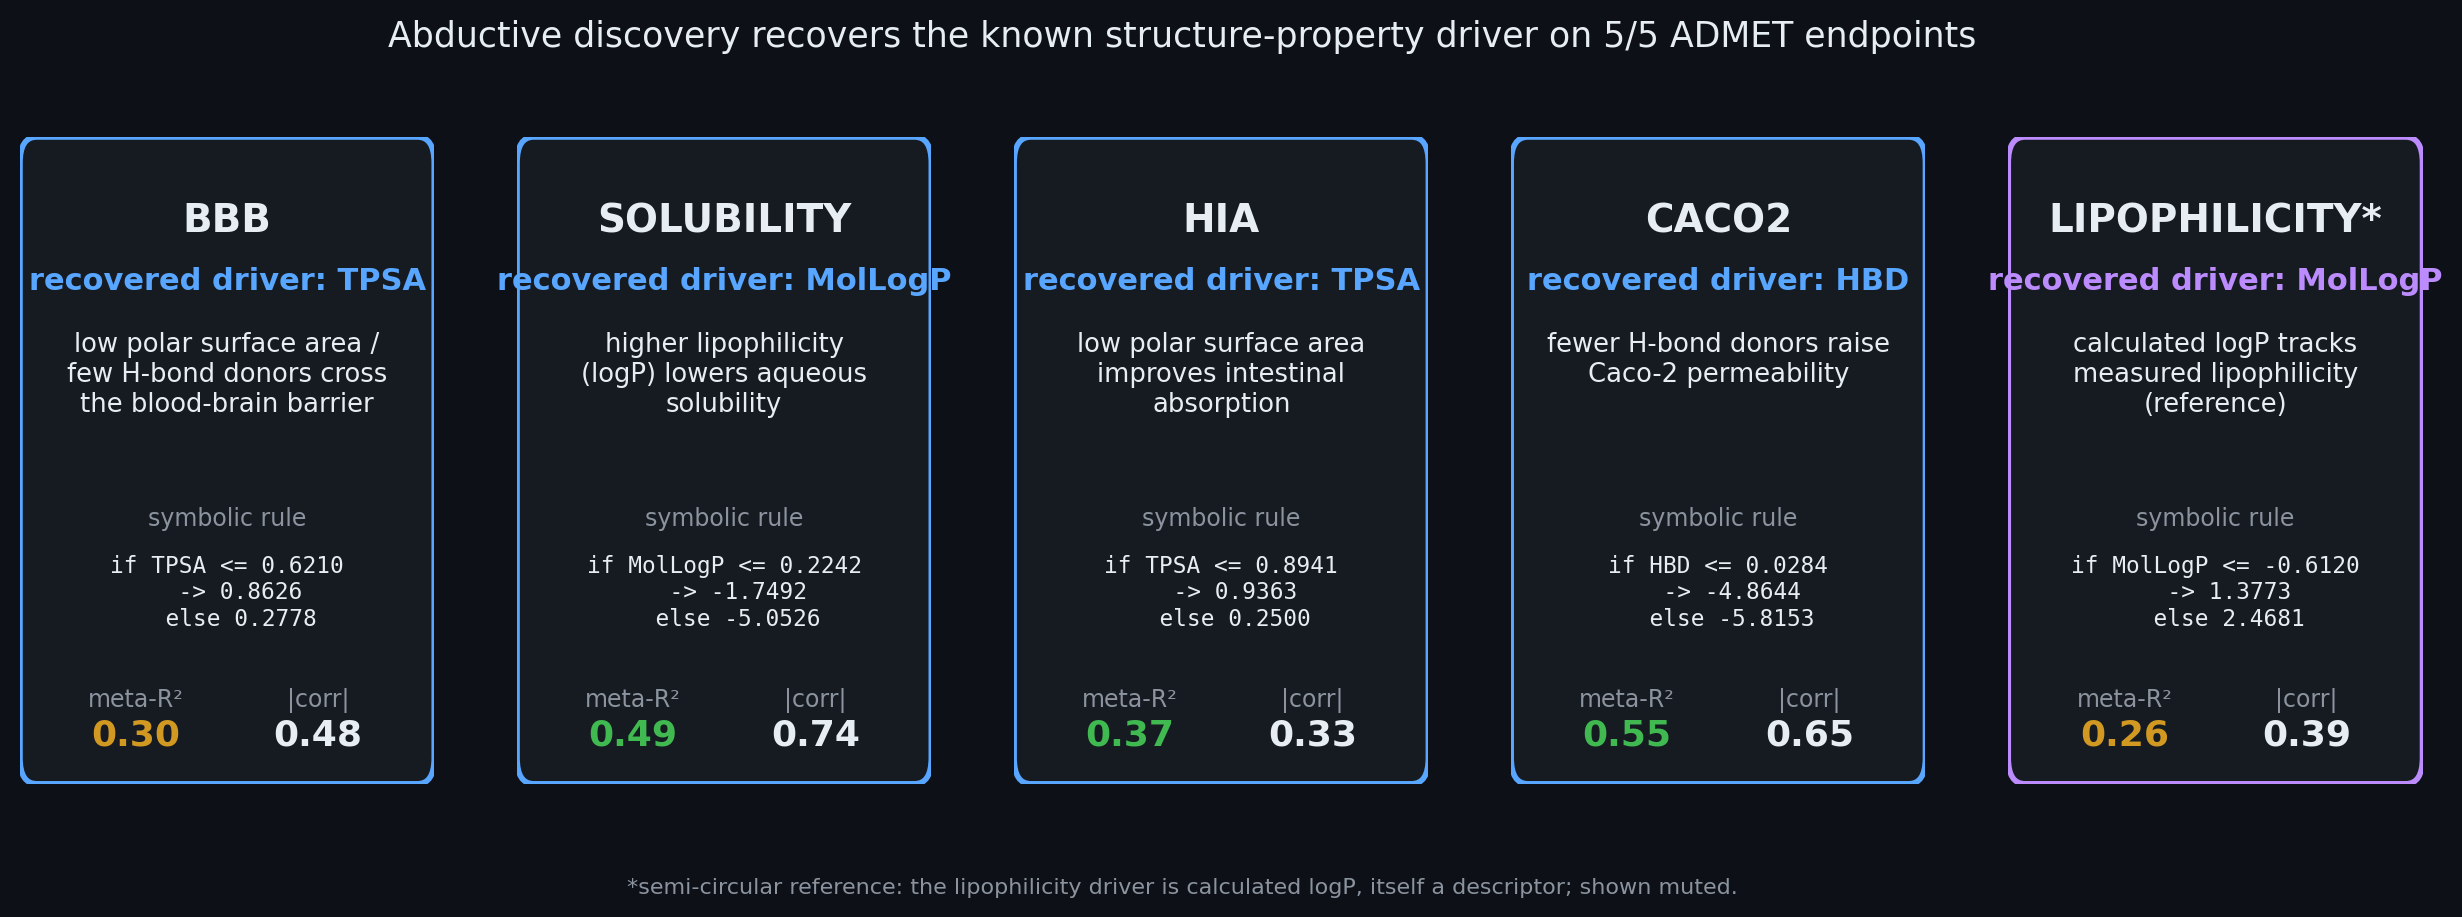

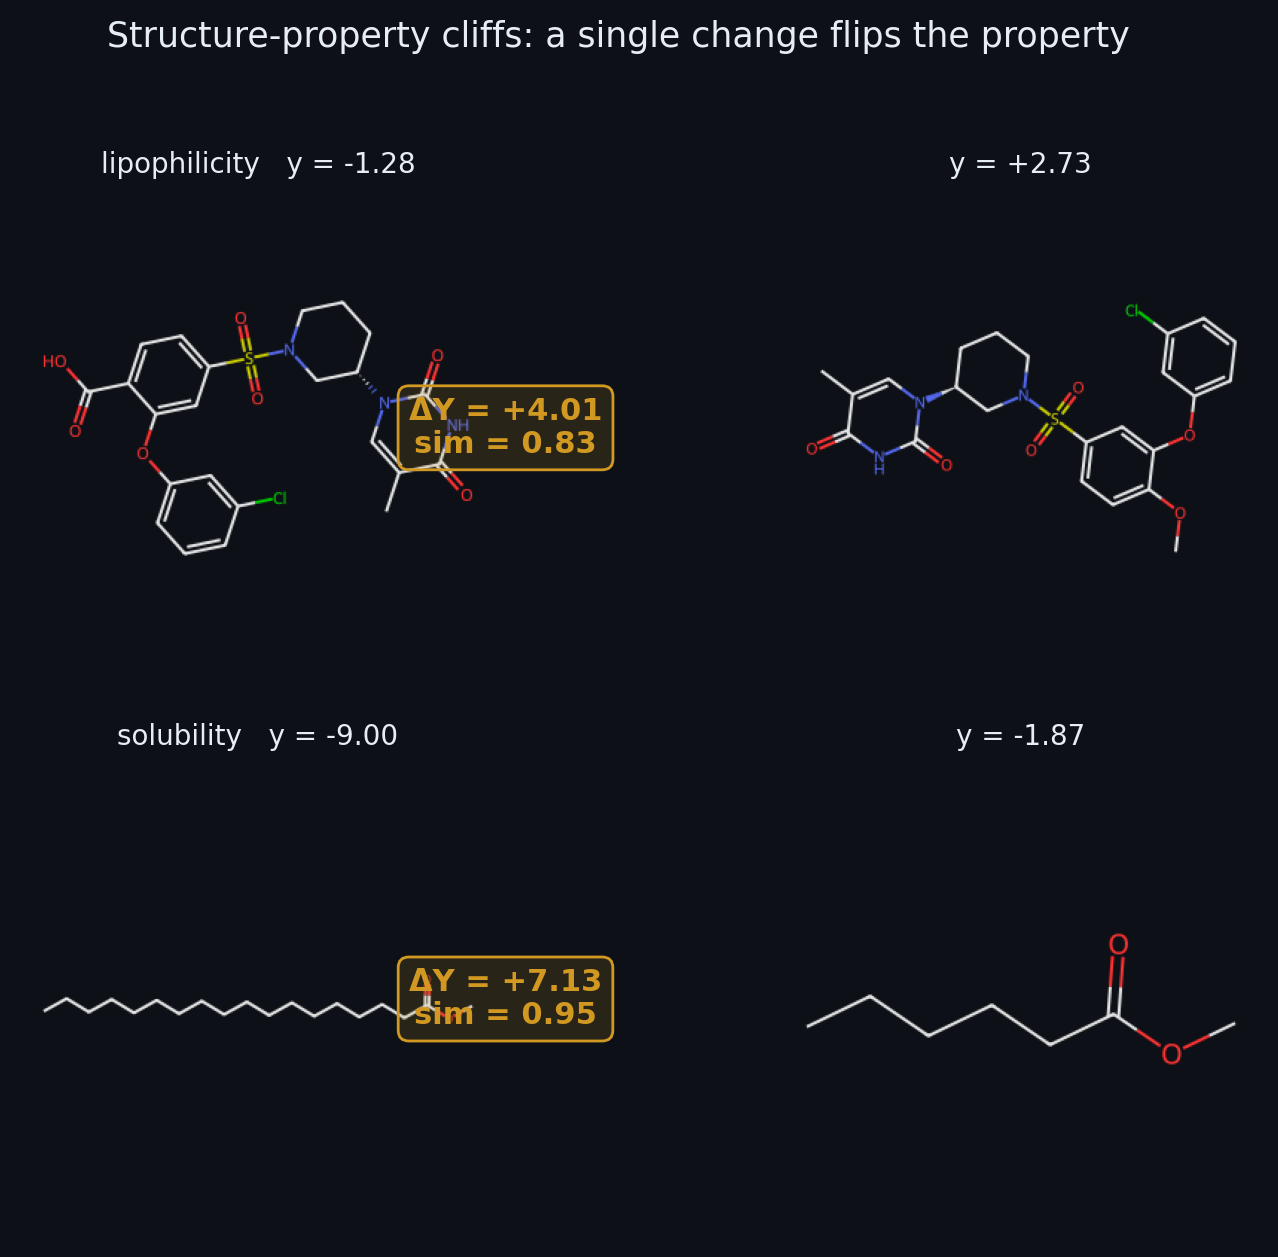

In [10]:
res = json.load(open(PRE / "e7_discovery_results.json"))
print("Abductive rule rediscovery:")
for r in res["rediscovery"]:
    print(f"  {r['endpoint']:14s} driver = {r['tree_feature']:8s} "
          f"meta-R2 = {r['meta_r2']:.2f}   recovered = {r['driver_hit']}")
n_cliffs = sum(b["n_cliffs"] for b in res["cliffs"])
print(f"\nstructure-property cliffs surfaced: {n_cliffs}")
display(Image(filename=str(FIG / "fig7_rule_cards.png")))
display(Image(filename=str(FIG / "fig8_cliff_panel.png")))

## 6. End-to-end autonomous campaign — E8

The wired engine runs a closed loop over six ADMET endpoints: calibrated oracle ->
SPRT go/no-go stopping -> abductive rule -> DuckDB lineage. Every decision is traced
from task to discovered rule.

E8 campaign: 6 GO / 0 NO-GO across 6 endpoints
measurements used 140 vs fixed 357  ->  61% saved

  bbb          GO (meaningful shift)      used  38 vs  68.7   rule = TPSA
  ames         GO (meaningful shift)      used  24 vs  68.7   rule = ArRings
  herg         GO (meaningful shift)      used  18 vs  49.0   rule = HeavyAtoms
  solubility   GO (meaningful shift)      used  10 vs  68.7   rule = MolLogP
  caco2        GO (meaningful shift)      used  17 vs  68.7   rule = HBD
  hia          GO (meaningful shift)      used  33 vs  33.0   rule = TPSA


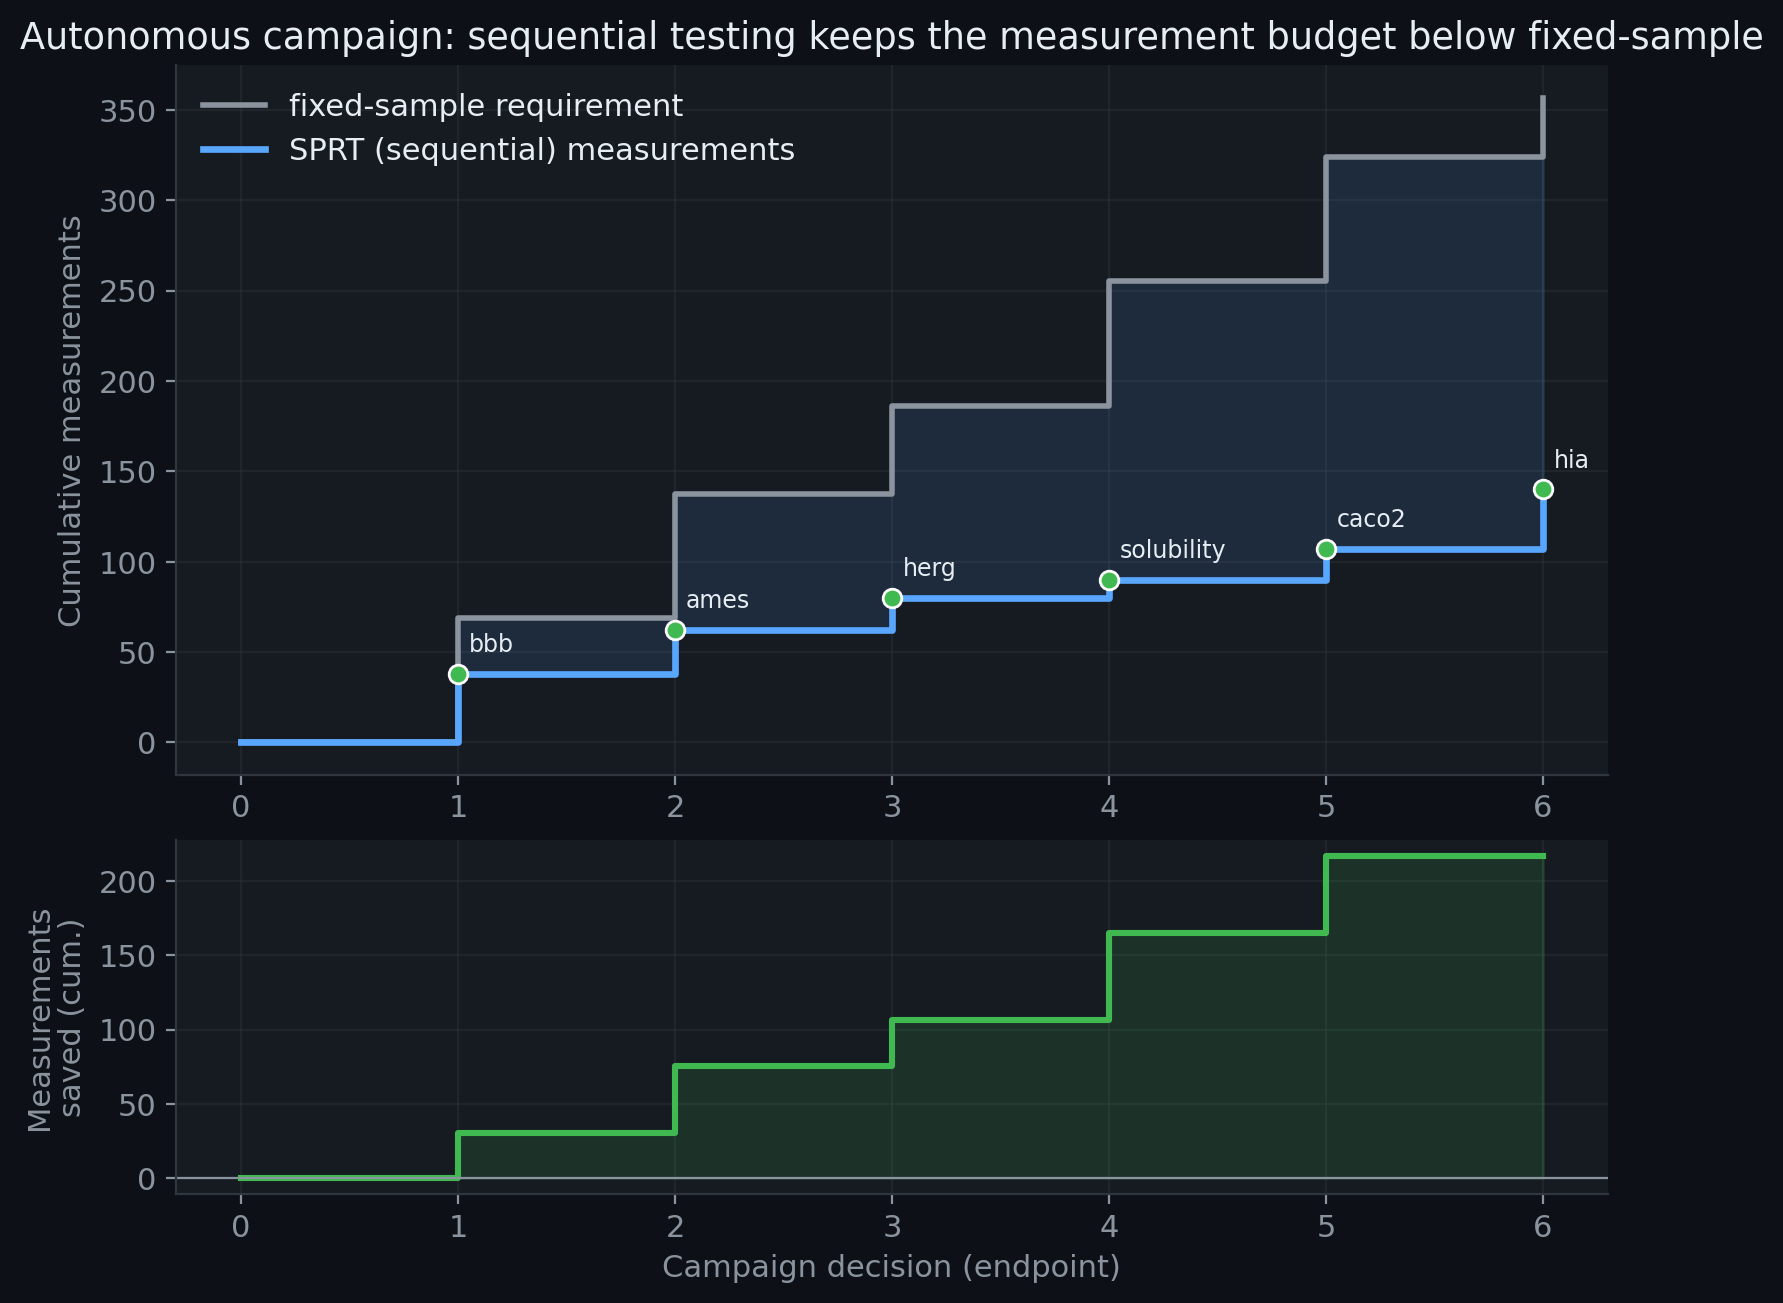

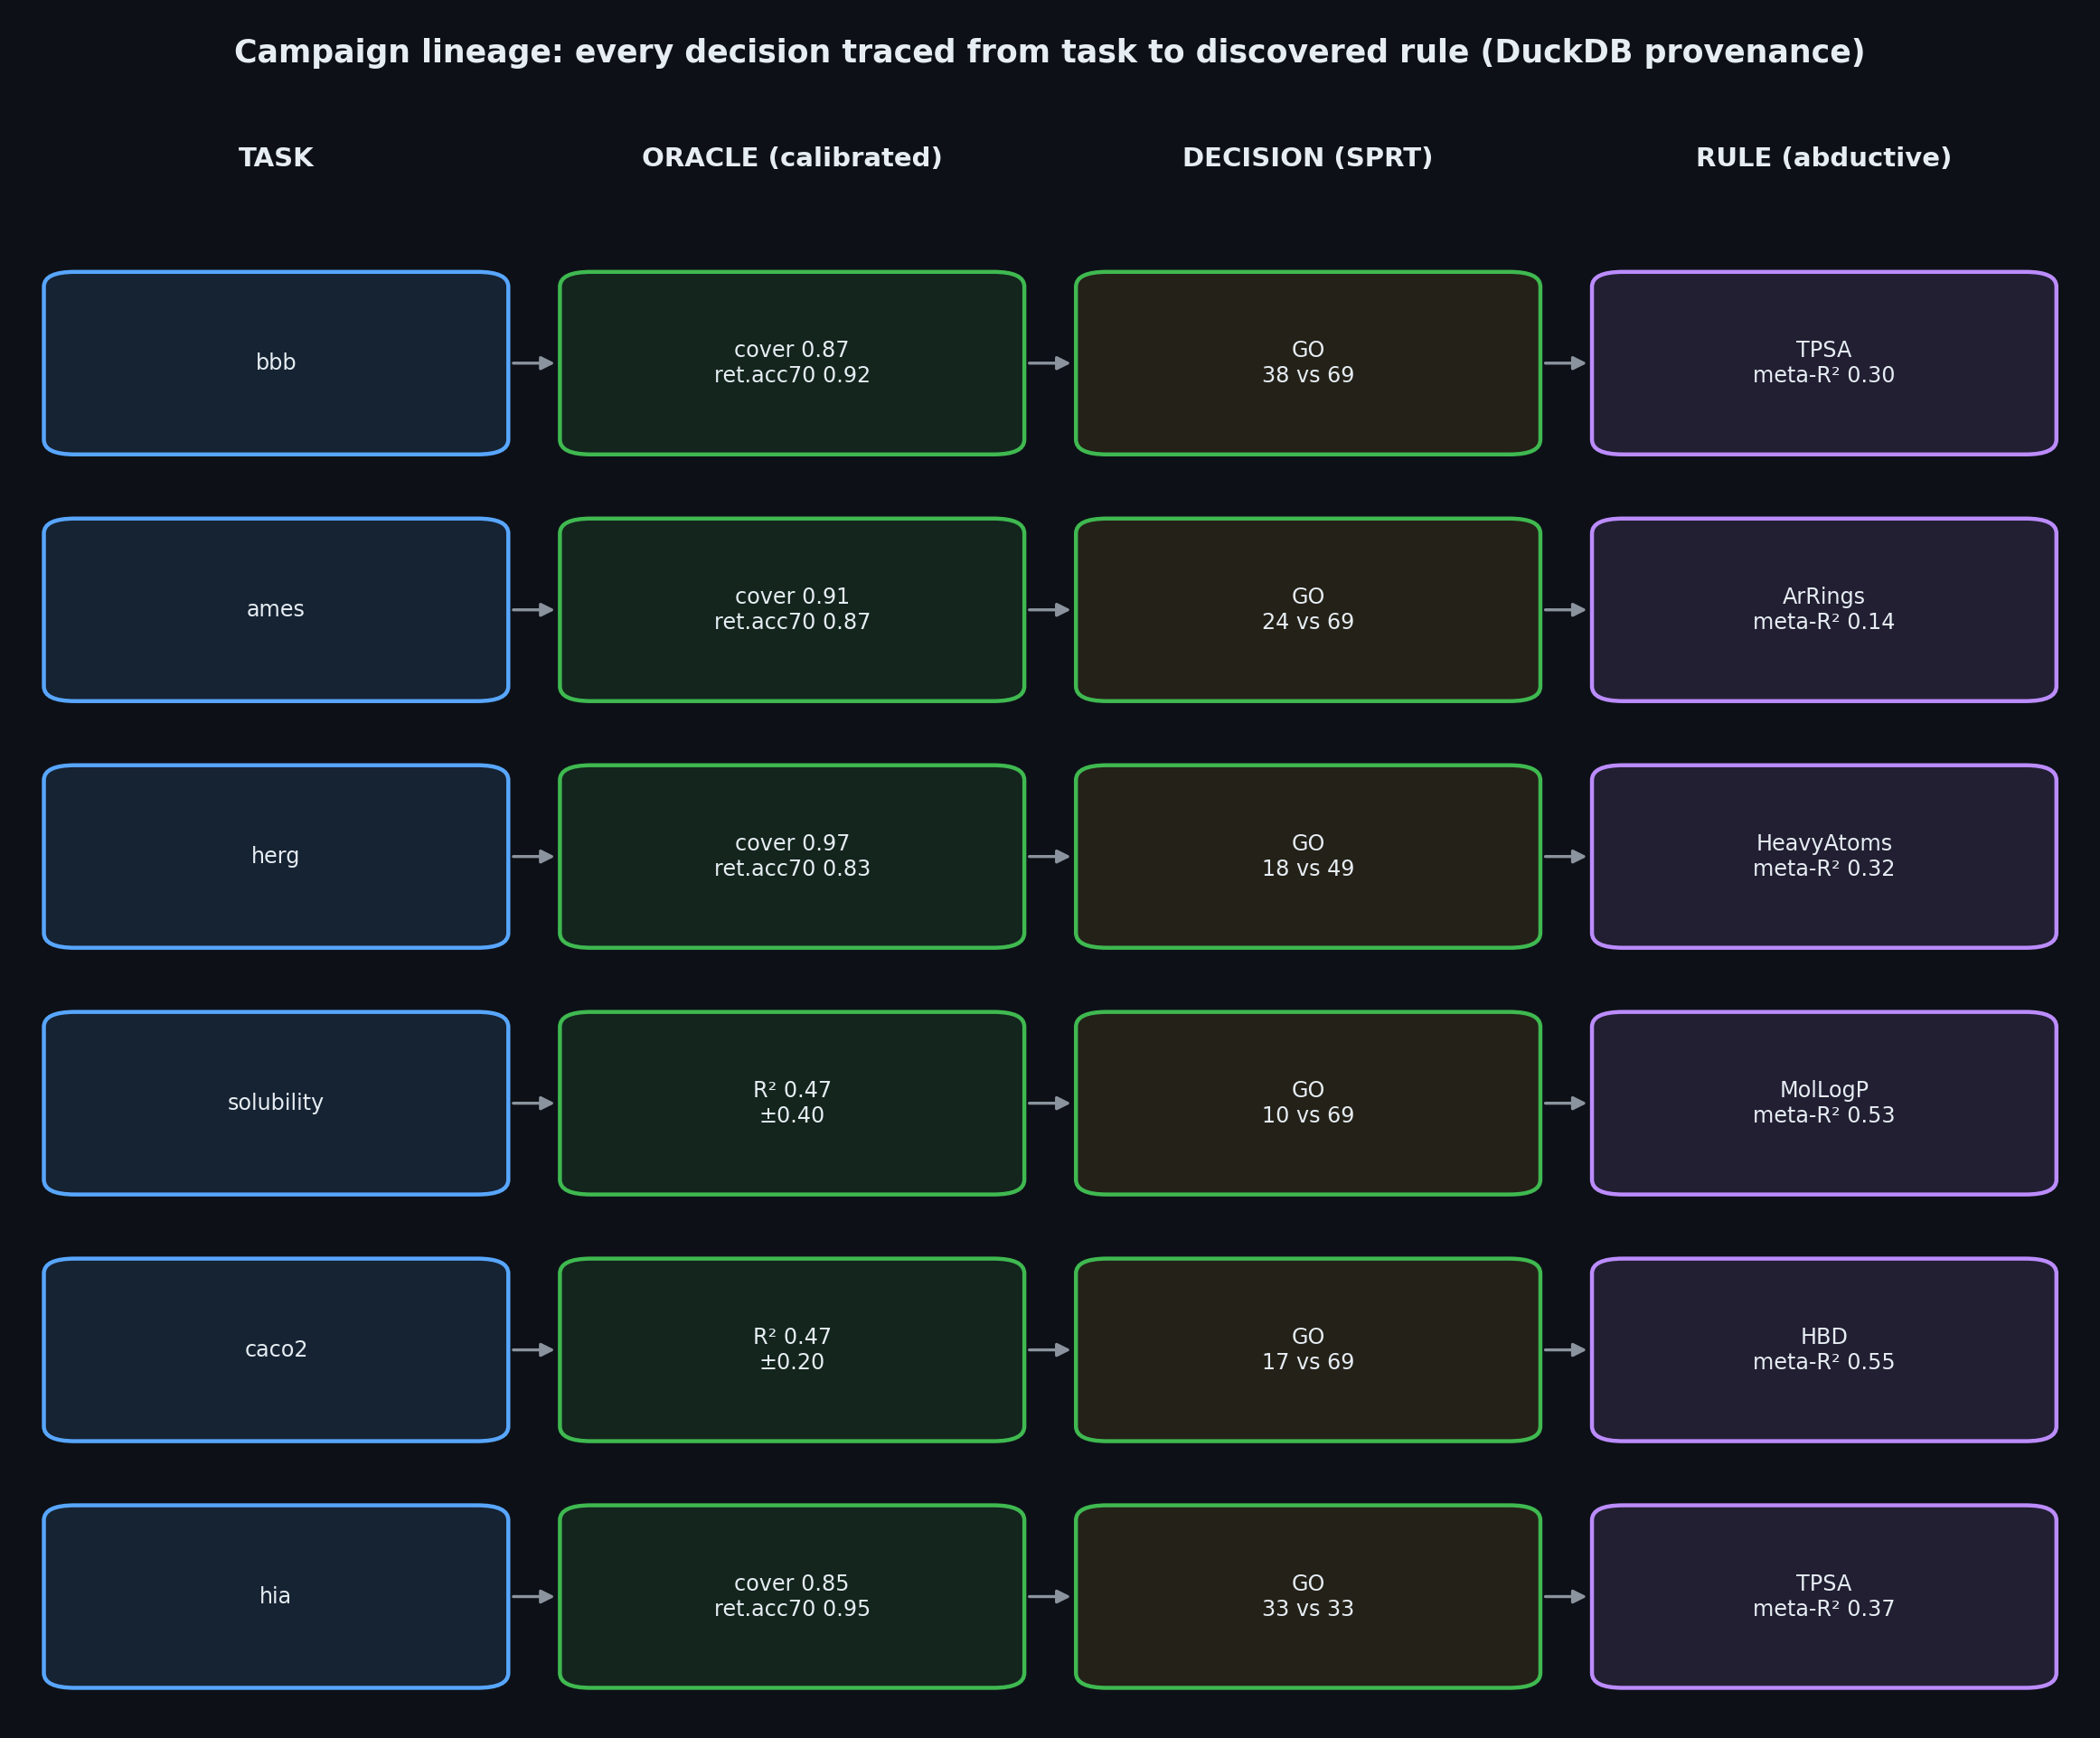

In [11]:
camp = json.load(open(PRE / "e8_campaign_results.json"))
print(f"E8 campaign: {camp['decisions_go']} GO / {camp['decisions_nogo']} NO-GO "
      f"across {camp['n_endpoints']} endpoints")
print(f"measurements used {camp['total_measurements_used']} vs fixed "
      f"{camp['total_fixed_sample']:.0f}  ->  {camp['fraction_saved'] * 100:.0f}% saved\n")
for r in camp["records"]:
    s = r["sprt"]
    print(f"  {r['endpoint']:12s} {s['verdict']:26s} used {s['n_measurements']:3d} "
          f"vs {s['fixed_sample_n']:5.1f}   rule = {r['rule']['tree_feature']}")
display(Image(filename=str(FIG / "fig9_campaign_timeline.png")))
display(Image(filename=str(FIG / "fig10_lineage_graph.png")))

## 7. Summary and how to fully regenerate

- **SPRT** reaches confident go/no-go calls with materially fewer measurements
  (61% fewer across the E8 campaign).
- **Conformal** coverage holds at target under scaffold shift; **selective prediction**
  raises retained accuracy by abstaining.
- **Abductive discovery** recovers known drivers (5/5) and surfaces activity cliffs.
- Every decision is **provenance-logged** to DuckDB.

**CPU vs GPU.** Everything above runs on CPU. The only GPU work in the wider project
was the deep-ensemble GIN acquisition study, which was *refuted* under hardening and
survives only as the pre-computed fig5 curves — no headline number depends on it.

Regenerate from the real Therapeutics Data Commons benchmarks:

```bash
make repro-spine       # E1-E5 spine + E7 discovery + rule cards
make repro-campaign    # E8 end-to-end campaign + timeline/lineage
```